In [1]:
import json
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

records = []
for path in glob.glob('results/medrag_*.json'):
    if 'neighbors' in path or 'ground' in path:
        continue
    label = re.search(r'medrag_(.+)\.json', path).group(1)
    with open(path) as f:
        for r in json.load(f)['results']:
            r['label'] = label
            records.append(r)

df = pd.DataFrame(records)
print(df.shape)
df.head()

(180, 16)


,seed,num_threads,beam_width,num_queries,catapults_enabled,bucket_capacity,num_hashes,elapsed_secs,qps,checksum,avg_dists_computed,avg_nodes_visited,searches_with_catapults,catapult_usage_pct,avg_catapults_added,label
0,42,4,1,10000,True,40,8,0.342255,29217.970928,167121984180,119.2739,2.1266,9346.0,93.46,0.9346,catapult
1,42,4,2,10000,True,40,8,0.488638,20465.041588,165076455164,182.6180,3.5813,9261.0,92.61,0.9261,catapult
2,42,4,4,10000,True,40,8,0.708161,14121.090213,170720887170,282.1218,5.9642,9211.0,92.11,0.9211,catapult
3,42,4,8,10000,True,40,8,1.412370,7080.295676,173597222736,461.5179,10.3029,9137.0,91.37,0.9137,catapult
4,42,4,16,10000,True,40,8,2.038014,4906.737014,174837543736,800.3555,18.5023,9095.0,90.95,0.9095,catapult


In [2]:
import os

# Average across seeds
agg = df.groupby(['label', 'num_threads', 'beam_width']).agg(
    qps=('qps', 'mean'),
    avg_dists_computed=('avg_dists_computed', 'mean'),
    avg_nodes_visited=('avg_nodes_visited', 'mean'),
    catapult_usage_pct=('catapult_usage_pct', 'mean'),
).reset_index()

threads = sorted(agg['num_threads'].unique())
beam_widths = sorted(agg['beam_width'].unique())
labels = sorted(agg['label'].unique())

colors = {'catapult': '#1f77b4', 'vanilla': '#ff7f0e', 'lshapg': '#2ca02c'}
markers = {'catapult': 'o', 'vanilla': 's', 'lshapg': '^'}

# fallback for any unexpected label
import itertools
_extra_colors = itertools.cycle(['#9467bd', '#8c564b', '#e377c2'])
_extra_markers = itertools.cycle(['D', 'P', 'X'])
for lbl in labels:
    if lbl not in colors:
        colors[lbl] = next(_extra_colors)
        markers[lbl] = next(_extra_markers)

os.makedirs('figures/medrag', exist_ok=True)
print('figures/medrag/ ready')

figures/medrag/ ready


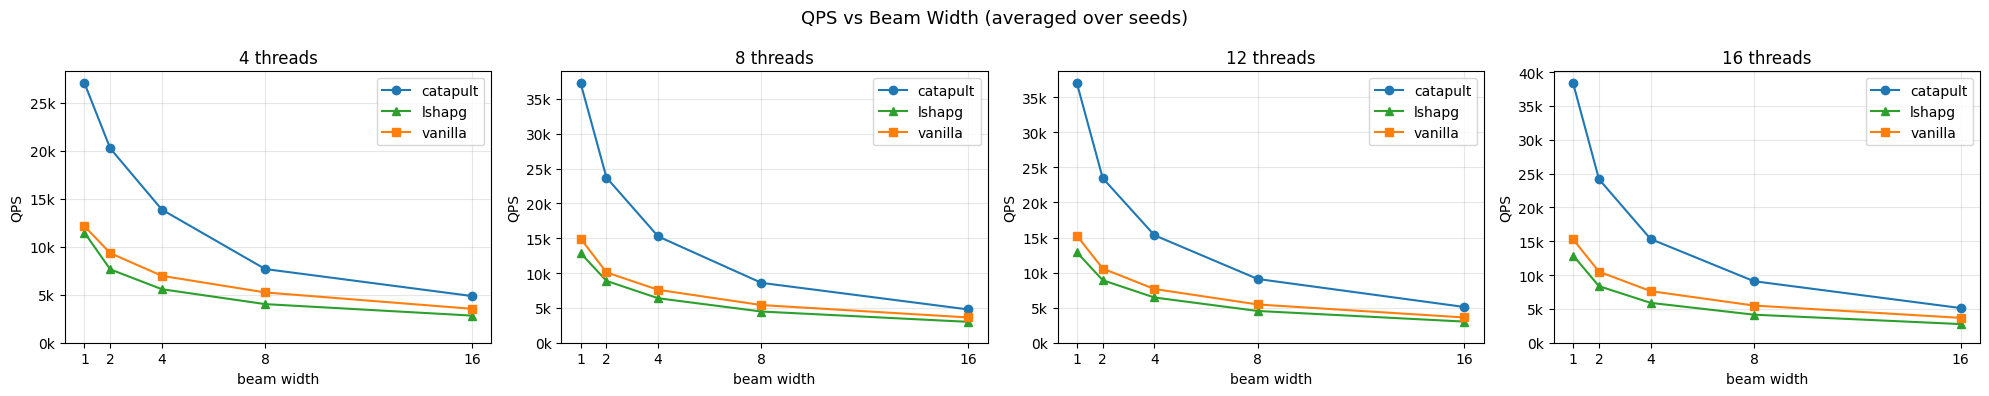

In [3]:
# Plot 1: QPS vs beam_width per num_threads
csv = agg[['label', 'num_threads', 'beam_width', 'qps']]
csv.to_csv('figures/medrag/plot1_qps_vs_beamwidth.csv', index=False)

fig, axes = plt.subplots(1, len(threads), figsize=(5 * len(threads), 4), sharey=False)
for ax, t in zip(axes, threads):
    for lbl in labels:
        sub = agg[(agg['label'] == lbl) & (agg['num_threads'] == t)].sort_values('beam_width')
        ax.plot(sub['beam_width'], sub['qps'], marker=markers[lbl], color=colors[lbl], label=lbl)
    ax.set_title(f'{t} threads')
    ax.set_xlabel('beam width')
    ax.set_ylabel('QPS')
    ax.set_ylim(0, None)
    ax.set_xticks(beam_widths)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.suptitle('QPS vs Beam Width (averaged over seeds)', fontsize=13)
plt.tight_layout()
fig.savefig('figures/medrag/plot1_qps_vs_beamwidth.png', dpi=150)
plt.show()

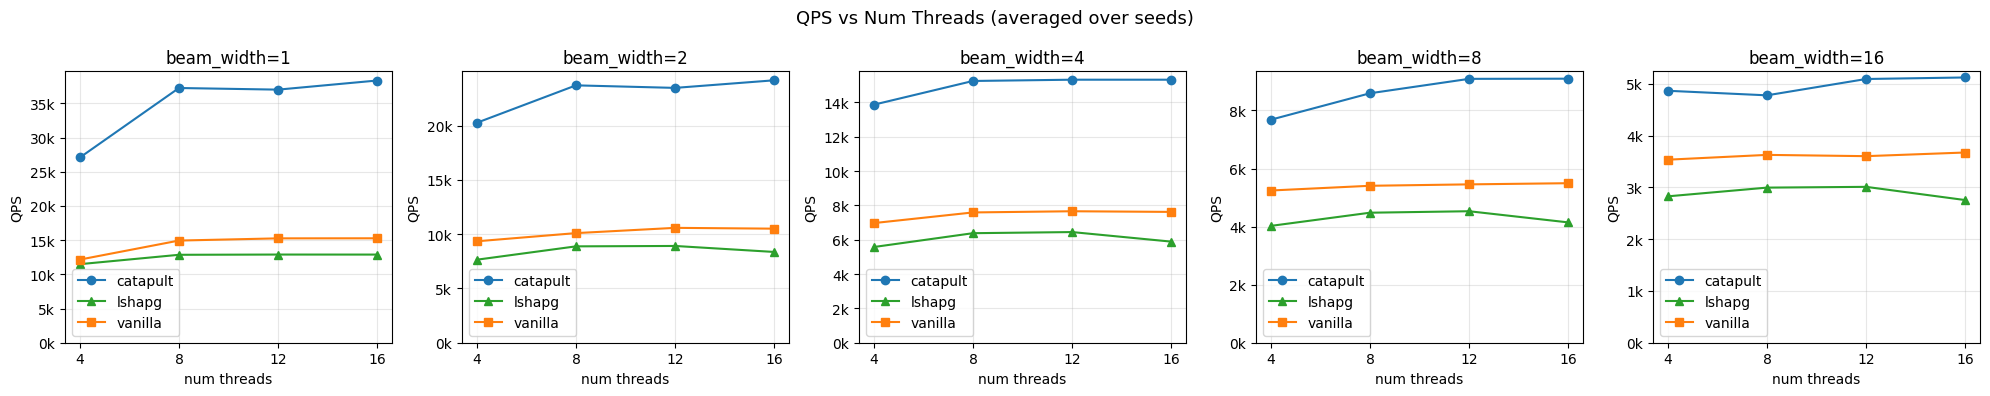

In [4]:
# Plot 2: QPS vs num_threads per beam_width
csv = agg[['label', 'num_threads', 'beam_width', 'qps']]
csv.to_csv('figures/medrag/plot2_qps_vs_threads.csv', index=False)

fig, axes = plt.subplots(1, len(beam_widths), figsize=(4 * len(beam_widths), 4), sharey=False)
for ax, bw in zip(axes, beam_widths):
    for lbl in labels:
        sub = agg[(agg['label'] == lbl) & (agg['beam_width'] == bw)].sort_values('num_threads')
        ax.plot(sub['num_threads'], sub['qps'], marker=markers[lbl], color=colors[lbl], label=lbl)
    ax.set_title(f'beam_width={bw}')
    ax.set_xlabel('num threads')
    ax.set_ylim(0, None)
    ax.set_ylabel('QPS')
    ax.set_xticks(threads)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.suptitle('QPS vs Num Threads (averaged over seeds)', fontsize=13)
plt.tight_layout()
fig.savefig('figures/medrag/plot2_qps_vs_threads.png', dpi=150)
plt.show()

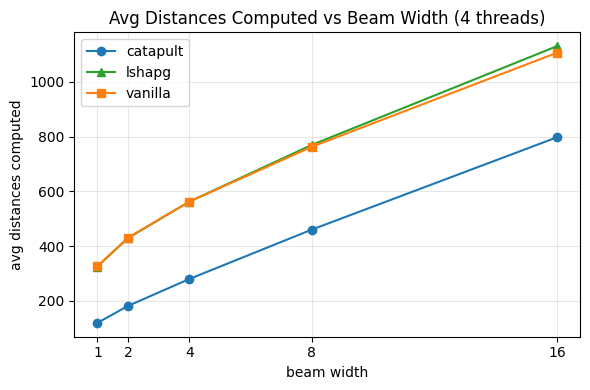

In [5]:
# Plot 3: avg_dists_computed vs beam_width — all variants
csv = agg[['label', 'num_threads', 'beam_width', 'avg_dists_computed']]
csv.to_csv('figures/medrag/plot3_avg_dists.csv', index=False)

t = threads[0]
fig, ax = plt.subplots(figsize=(6, 4))
for lbl in labels:
    sub = agg[(agg['label'] == lbl) & (agg['num_threads'] == t)].sort_values('beam_width')
    ax.plot(sub['beam_width'], sub['avg_dists_computed'], marker=markers[lbl], color=colors[lbl], label=lbl)
ax.set_xlabel('beam width')
ax.set_ylabel('avg distances computed')
ax.set_xticks(beam_widths)
ax.set_title(f'Avg Distances Computed vs Beam Width ({t} threads)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('figures/medrag/plot3_avg_dists.png', dpi=150)
plt.show()

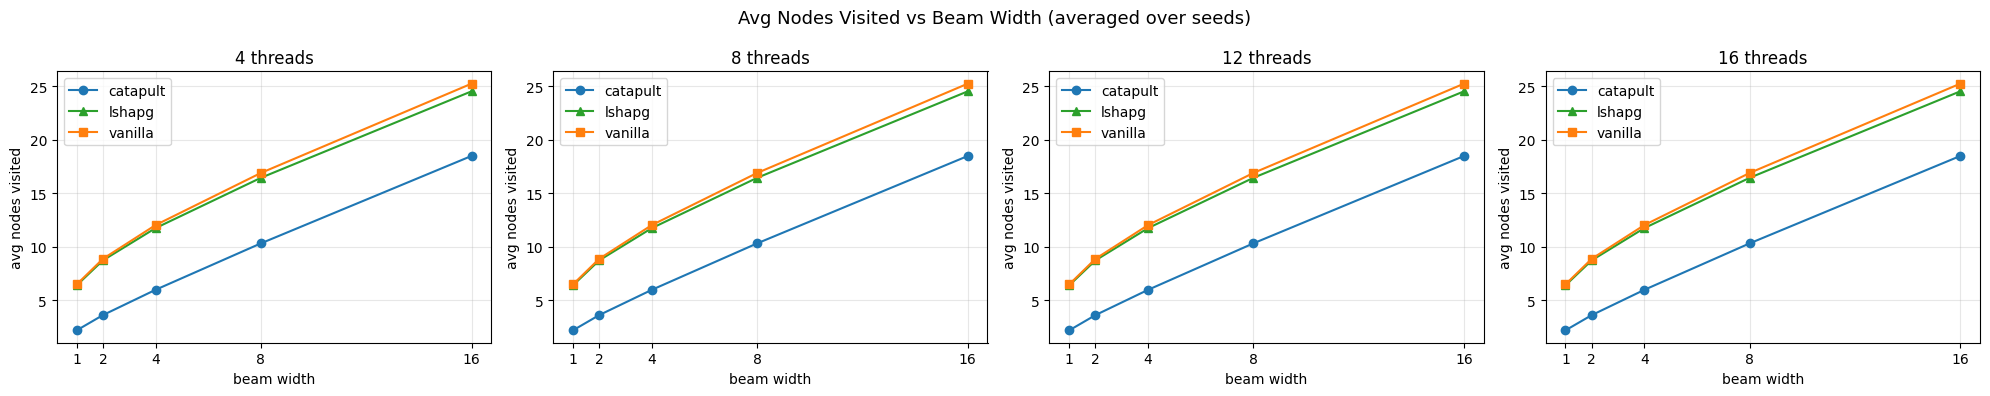

In [6]:
# Plot 3b: avg_nodes_visited vs beam_width per num_threads
csv = agg[['label', 'num_threads', 'beam_width', 'avg_nodes_visited']]
csv.to_csv('figures/medrag/plot3b_avg_nodes.csv', index=False)

fig, axes = plt.subplots(1, len(threads), figsize=(5 * len(threads), 4), sharey=False)
for ax, t in zip(axes, threads):
    for lbl in labels:
        sub = agg[(agg['label'] == lbl) & (agg['num_threads'] == t)].sort_values('beam_width')
        ax.plot(sub['beam_width'], sub['avg_nodes_visited'], marker=markers[lbl], color=colors[lbl], label=lbl)
    ax.set_title(f'{t} threads')
    ax.set_xlabel('beam width')
    ax.set_ylabel('avg nodes visited')
    ax.set_xticks(beam_widths)
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.suptitle('Avg Nodes Visited vs Beam Width (averaged over seeds)', fontsize=13)
plt.tight_layout()
fig.savefig('figures/medrag/plot3b_avg_nodes.png', dpi=150)
plt.show()

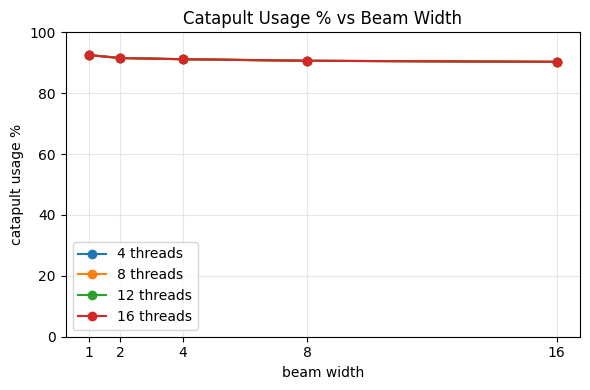

In [7]:
# Plot 4: catapult usage % vs beam_width
cat = agg[agg['label'] == 'catapult'][['num_threads', 'beam_width', 'catapult_usage_pct']]
cat.to_csv('figures/medrag/plot4_catapult_usage.csv', index=False)

fig, ax = plt.subplots(figsize=(6, 4))
for t in threads:
    sub = cat[cat['num_threads'] == t].sort_values('beam_width')
    ax.plot(sub['beam_width'], sub['catapult_usage_pct'], marker='o', label=f'{t} threads')
ax.set_xlabel('beam width')
ax.set_ylabel('catapult usage %')
ax.set_xticks(beam_widths)
ax.set_ylim(0, 100)
ax.set_title('Catapult Usage % vs Beam Width')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('figures/medrag/plot4_catapult_usage.png', dpi=150)
plt.show()

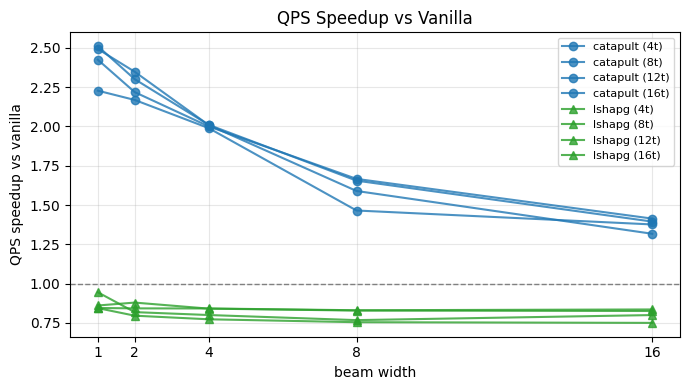

In [8]:
# Plot 5: QPS speedup ratio vs vanilla per beam_width per num_threads
van_df = agg[agg['label'] == 'vanilla'].set_index(['num_threads', 'beam_width'])['qps']
non_vanilla = [lbl for lbl in labels if lbl != 'vanilla']

speedup_rows = []
for lbl in non_vanilla:
    for t in threads:
        sub = agg[(agg['label'] == lbl) & (agg['num_threads'] == t)].sort_values('beam_width')
        speedup = sub.set_index('beam_width')['qps'] / van_df.xs(t, level='num_threads')
        for bw, s in speedup.items():
            speedup_rows.append({'label': lbl, 'num_threads': t, 'beam_width': bw, 'speedup': s})

speedup_df = pd.DataFrame(speedup_rows)
speedup_df.to_csv('figures/medrag/plot5_qps_speedup.csv', index=False)

fig, ax = plt.subplots(figsize=(7, 4))
for lbl in non_vanilla:
    for t in threads:
        sub = speedup_df[(speedup_df['label'] == lbl) & (speedup_df['num_threads'] == t)].sort_values('beam_width')
        ax.plot(sub['beam_width'], sub['speedup'], marker=markers[lbl], color=colors[lbl],
                label=f'{lbl} ({t}t)', alpha=0.8)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('beam width')
ax.set_ylabel('QPS speedup vs vanilla')
ax.set_xticks(beam_widths)
ax.set_title('QPS Speedup vs Vanilla')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('figures/medrag/plot5_qps_speedup.png', dpi=150)
plt.show()

In [9]:
def recall(a, b):
    return len(set(a) & set(b)) / len(set(a))

ground_truth_path = 'results/medrag_ground_truth.json'
with open(ground_truth_path) as f:
    ground_truth = json.load(f)['results'][0]['neighbors']

recall_rows = []
for path in glob.glob('results/medrag_*_neighbors.json'):
    mode = re.search(r'medrag_(.+)_neighbors\.json', path).group(1)
    with open(path) as f:
        results = json.load(f)['results']
    for r in results:
        avg_recall = sum(
            recall(ground_truth[i][:len(q)], q)
            for i, q in enumerate(r['neighbors'])
        ) / len(r['neighbors'])
        recall_rows.append({
            'mode':        mode,
            'seed':        r['seed'],
            'num_threads': r['num_threads'],
            'beam_width':  r['beam_width'],
            'avg_recall':  avg_recall,
        })

recall_df = pd.DataFrame(recall_rows)
recall_df

,mode,seed,num_threads,beam_width,avg_recall
0,catapult,42,4,1,0.284300
1,catapult,42,4,2,0.459750
2,catapult,42,4,4,0.601000
3,catapult,42,4,8,0.712838
4,catapult,42,4,16,0.805569
...,...,...,...,...,...
175,lshapg,44,16,1,0.193600
176,lshapg,44,16,2,0.343000
177,lshapg,44,16,4,0.504175
178,lshapg,44,16,8,0.658525


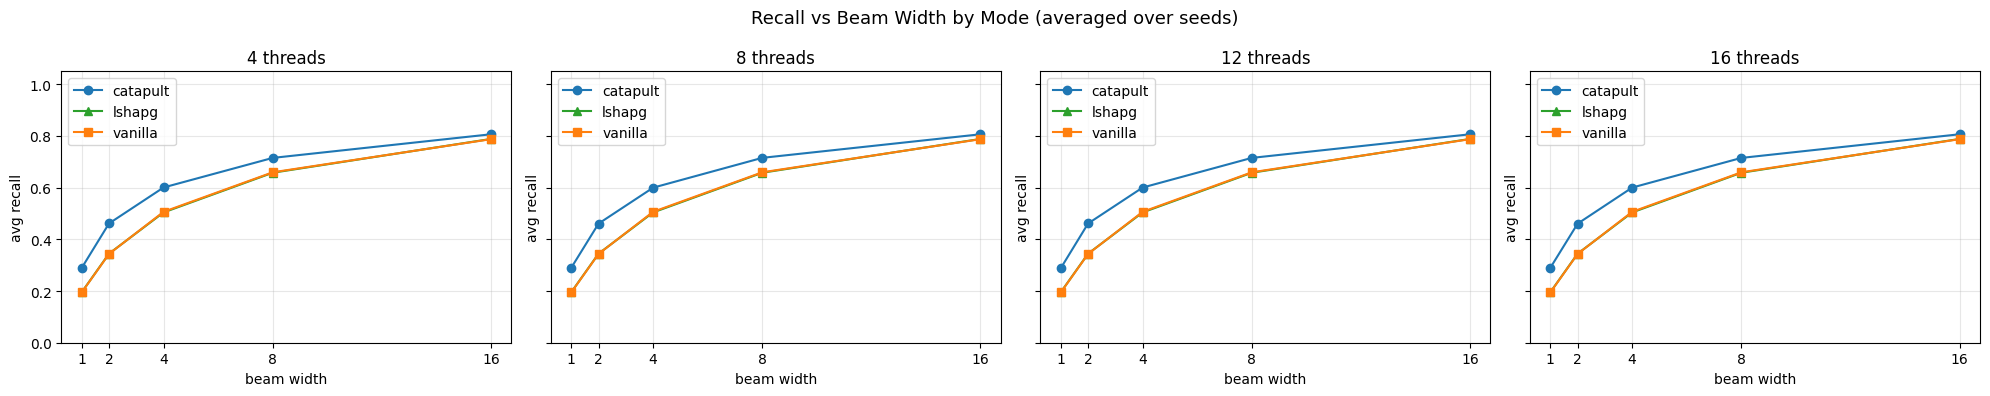

In [10]:
# Plot 6: Recall vs beam_width by mode, one subplot per num_threads (averaged over seeds)
recall_agg = recall_df.groupby(['mode', 'num_threads', 'beam_width'])['avg_recall'].mean().reset_index()
recall_agg.to_csv('figures/medrag/plot6_recall.csv', index=False)

recall_threads = sorted(recall_agg['num_threads'].unique())
fig, axes = plt.subplots(1, len(recall_threads), figsize=(5 * len(recall_threads), 4), sharey=True)
for ax, t in zip(axes, recall_threads):
    for mode in sorted(recall_agg['mode'].unique()):
        sub = recall_agg[(recall_agg['mode'] == mode) & (recall_agg['num_threads'] == t)].sort_values('beam_width')
        ax.plot(sub['beam_width'], sub['avg_recall'],
                marker=markers.get(mode, 'o'), color=colors.get(mode), label=mode)
    ax.set_title(f'{t} threads')
    ax.set_xlabel('beam width')
    ax.set_ylabel('avg recall')
    ax.set_xticks(sorted(recall_agg['beam_width'].unique()))
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.suptitle('Recall vs Beam Width by Mode (averaged over seeds)', fontsize=13)
plt.tight_layout()
fig.savefig('figures/medrag/plot6_recall.png', dpi=150)
plt.show()

In [11]:
# Relative % difference vs vanilla per beam_width, averaged over all threads (and seeds for recall)

perf_avg = agg.groupby(['label', 'beam_width']).agg(
    qps=('qps', 'mean'),
    avg_dists_computed=('avg_dists_computed', 'mean'),
    avg_nodes_visited=('avg_nodes_visited', 'mean'),
    catapult_usage_pct=('catapult_usage_pct', 'mean'),
).reset_index()

recall_avg = recall_df.groupby(['mode', 'beam_width'])['avg_recall'].mean().reset_index()
recall_avg.columns = ['label', 'beam_width', 'avg_recall']

combined = perf_avg.merge(recall_avg, on=['label', 'beam_width'], how='left')

vanilla = combined[combined['label'] == 'vanilla'].set_index('beam_width')
metrics = ['qps', 'avg_dists_computed', 'avg_nodes_visited', 'avg_recall']

rows = []
for lbl in sorted(combined['label'].unique()):
    if lbl == 'vanilla':
        continue
    sub = combined[combined['label'] == lbl].set_index('beam_width')
    for bw in sorted(sub.index):
        row = {'label': lbl, 'beam_width': bw, 'catapult_usage_pct': sub.loc[bw, 'catapult_usage_pct']}
        for m in metrics:
            v = vanilla.loc[bw, m] if bw in vanilla.index else float('nan')
            s = sub.loc[bw, m]
            row[f'{m}_rel_pct'] = (s - v) / abs(v) * 100 if (not pd.isna(v) and not pd.isna(s) and v != 0) else float('nan')
        rows.append(row)

rel_df = pd.DataFrame(rows)
rel_df.to_csv('figures/medrag/rel_pct_diff.csv', index=False)
display(rel_df.round(2))

# Per num_threads breakdown
recall_pt = recall_df.groupby(['mode', 'num_threads', 'beam_width'])['avg_recall'].mean().reset_index()
recall_pt.columns = ['label', 'num_threads', 'beam_width', 'avg_recall']

combined_pt = agg.merge(recall_pt, on=['label', 'num_threads', 'beam_width'], how='left')
vanilla_pt = combined_pt[combined_pt['label'] == 'vanilla'].set_index(['num_threads', 'beam_width'])

rows_pt = []
for lbl in sorted(combined_pt['label'].unique()):
    if lbl == 'vanilla':
        continue
    sub = combined_pt[combined_pt['label'] == lbl].set_index(['num_threads', 'beam_width'])
    for idx in sorted(sub.index):
        t, bw = idx
        row = {'label': lbl, 'num_threads': t, 'beam_width': bw, 'catapult_usage_pct': sub.loc[idx, 'catapult_usage_pct']}
        for m in metrics:
            v = vanilla_pt.loc[idx, m] if idx in vanilla_pt.index else float('nan')
            s = sub.loc[idx, m]
            row[f'{m}_rel_pct'] = (s - v) / abs(v) * 100 if (not pd.isna(v) and not pd.isna(s) and v != 0) else float('nan')
        rows_pt.append(row)

rel_df_pt = pd.DataFrame(rows_pt)
rel_df_pt.to_csv('figures/medrag/rel_pct_diff_per_thread.csv', index=False)
rel_df_pt.round(2)

,label,beam_width,catapult_usage_pct,qps_rel_pct,avg_dists_computed_rel_pct,avg_nodes_visited_rel_pct,avg_recall_rel_pct
0,catapult,1,92.53,142.39,-63.54,-66.40,48.59
1,catapult,2,91.56,126.06,-57.95,-59.37,34.20
2,catapult,4,91.17,100.27,-50.29,-50.35,18.52
3,catapult,8,90.66,59.54,-39.68,-38.97,8.46
4,catapult,16,90.31,37.54,-27.95,-26.79,2.41
5,lshapg,1,NaN,-13.01,-0.49,-1.29,0.31
6,lshapg,2,NaN,-16.60,-0.27,-1.63,0.28
7,lshapg,4,NaN,-18.59,-0.03,-2.36,-0.47
8,lshapg,8,NaN,-20.47,0.89,-2.69,-0.25
9,lshapg,16,NaN,-19.74,2.16,-2.84,0.12


,label,num_threads,beam_width,catapult_usage_pct,qps_rel_pct,avg_dists_computed_rel_pct,avg_nodes_visited_rel_pct,avg_recall_rel_pct
0,catapult,4,1,92.50,122.79,-63.57,-66.41,48.58
1,catapult,4,2,91.63,116.87,-57.94,-59.35,34.32
2,catapult,4,4,91.17,98.96,-50.30,-50.33,18.60
3,catapult,4,8,90.65,46.52,-39.70,-38.97,8.45
4,catapult,4,16,90.29,37.65,-27.94,-26.78,2.41
5,catapult,8,1,92.53,149.32,-63.50,-66.40,48.89
6,catapult,8,2,91.55,134.80,-57.95,-59.36,34.14
7,catapult,8,4,91.15,100.91,-50.28,-50.36,18.44
8,catapult,8,8,90.66,58.95,-39.69,-38.98,8.48
9,catapult,8,16,90.32,31.71,-27.96,-26.79,2.41


Catapult vs LSHAPG (averaged over threads & seeds, % diff):


,beam_width,qps_rel_pct,avg_dists_computed_rel_pct,avg_nodes_visited_rel_pct,avg_recall_rel_pct
0,1,178.66,-63.36,-65.96,48.13
1,2,171.06,-57.84,-58.70,33.83
2,4,146.00,-50.28,-49.15,19.08
3,8,100.61,-40.21,-37.29,8.73
4,16,71.38,-29.48,-24.65,2.29



Catapult vs LSHAPG per num_threads (% diff):


,num_threads,beam_width,qps_rel_pct,avg_dists_computed_rel_pct,avg_nodes_visited_rel_pct,avg_recall_rel_pct
0,4,1,135.77,-63.39,-65.97,48.12
1,4,2,164.95,-57.83,-58.68,33.95
2,4,4,148.70,-50.28,-49.14,19.15
3,4,8,90.88,-40.23,-37.29,8.72
4,4,16,72.11,-29.46,-24.64,2.29
5,8,1,189.68,-63.32,-65.96,48.43
6,8,2,167.07,-57.84,-58.69,33.77
7,8,4,138.98,-50.27,-49.16,19.00
8,8,8,91.87,-40.22,-37.29,8.76
9,8,16,59.50,-29.48,-24.65,2.29


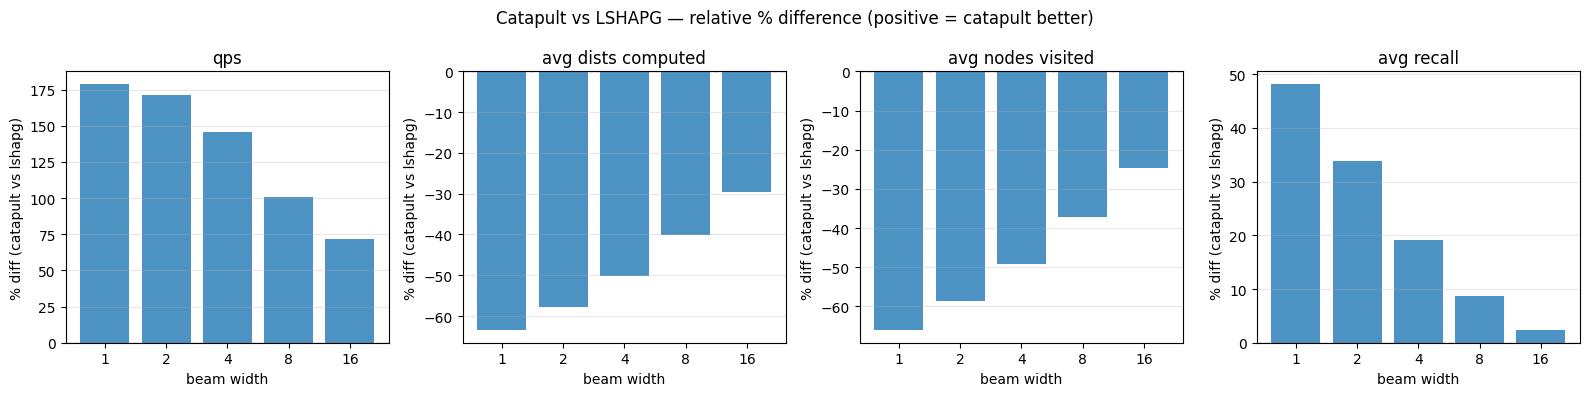

In [12]:
# Relative comparison: catapult vs lshapg (catapult / lshapg - 1) * 100

metrics = ['qps', 'avg_dists_computed', 'avg_nodes_visited', 'avg_recall']

# --- averaged over threads and seeds ---
lshapg_avg  = combined[combined['label'] == 'lshapg'].set_index('beam_width')
catapult_avg = combined[combined['label'] == 'catapult'].set_index('beam_width')

rows_cl = []
for bw in sorted(catapult_avg.index):
    row = {'beam_width': bw}
    for m in metrics:
        c = catapult_avg.loc[bw, m] if bw in catapult_avg.index else float('nan')
        l = lshapg_avg.loc[bw, m]   if bw in lshapg_avg.index  else float('nan')
        row[f'{m}_rel_pct'] = (c - l) / abs(l) * 100 if (not pd.isna(c) and not pd.isna(l) and l != 0) else float('nan')
    rows_cl.append(row)

rel_cat_vs_lsh = pd.DataFrame(rows_cl)
rel_cat_vs_lsh.to_csv('figures/medrag/rel_pct_catapult_vs_lshapg.csv', index=False)
print("Catapult vs LSHAPG (averaged over threads & seeds, % diff):")
display(rel_cat_vs_lsh.round(2))

# --- per num_threads breakdown ---
lshapg_pt   = combined_pt[combined_pt['label'] == 'lshapg'].set_index(['num_threads', 'beam_width'])
catapult_pt = combined_pt[combined_pt['label'] == 'catapult'].set_index(['num_threads', 'beam_width'])

rows_cl_pt = []
for idx in sorted(catapult_pt.index):
    t, bw = idx
    row = {'num_threads': t, 'beam_width': bw}
    for m in metrics:
        c = catapult_pt.loc[idx, m] if idx in catapult_pt.index else float('nan')
        l = lshapg_pt.loc[idx, m]   if idx in lshapg_pt.index  else float('nan')
        row[f'{m}_rel_pct'] = (c - l) / abs(l) * 100 if (not pd.isna(c) and not pd.isna(l) and l != 0) else float('nan')
    rows_cl_pt.append(row)

rel_cat_vs_lsh_pt = pd.DataFrame(rows_cl_pt)
rel_cat_vs_lsh_pt.to_csv('figures/medrag/rel_pct_catapult_vs_lshapg_per_thread.csv', index=False)
print("\nCatapult vs LSHAPG per num_threads (% diff):")
display(rel_cat_vs_lsh_pt.round(2))

# --- bar chart: catapult % gain over lshapg by beam_width ---
fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4), sharey=False)
for ax, m in zip(axes, metrics):
    ax.bar(rel_cat_vs_lsh['beam_width'].astype(str), rel_cat_vs_lsh[f'{m}_rel_pct'],
           color='#1f77b4', alpha=0.8)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('beam width')
    ax.set_ylabel('% diff (catapult vs lshapg)')
    ax.set_title(m.replace('_', ' '))
    ax.grid(True, alpha=0.3, axis='y')
fig.suptitle('Catapult vs LSHAPG — relative % difference (positive = catapult better)', fontsize=12)
plt.tight_layout()
fig.savefig('figures/medrag/plot7_catapult_vs_lshapg.png', dpi=150)
plt.show()